[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/16_scipy.ipynb)

# SciPy(Scientific Python) : le calcul scientifique

NumPy fournit les tableaux et les opérations élémentaires. SciPy est la couche
au-dessus : interpolation, optimisation, traitement du signal, traitement
d'images, statistiques. Ce sont les outils qu'on utilise quand on a des données
réelles, donc imparfaites.

## Les cinq modules du notebook

| Module | Ce qu'il fait | Le problème qu'il résout |
|---|---|---|
| `interpolate` | reconstruit une fonction entre des points connus | j'ai dix mesures, j'en veux cent |
| `optimize` | ajuste un modèle, cherche un minimum | quelle courbe passe au mieux par mes points ? |
| `signal` | traite les signaux | mes données ont une tendance parasite |
| `fft` | analyse les fréquences | quelles périodicités se cachent dans mon signal ? |
| `ndimage` | traite les images | combien d'objets y a-t-il sur cette photo ? |

## La démarche

Comme dans les notebooks précédents, on trace d'abord la version naïve, on
regarde ce qui cloche, on corrige. Plusieurs cellules contiennent des erreurs
volontairement conservées, parce que ce sont exactement celles qu'on commet la
première fois.

Deux d'entre elles sont particulièrement instructives : un calcul de fréquences
faux mais crédible, et un comptage d'objets qui oublie systématiquement le
dernier. Aucune des deux ne lève d'erreur.

Prérequis : NumPy, et les deux notebooks Matplotlib.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Interpolation

Le problème : on dispose de quelques points de mesure et on veut une valeur là
où l'on n'a pas mesuré. L'interpolation construit une fonction qui passe
exactement par les points connus, et qui donne une estimation entre eux.

Attention à la distinction avec la régression, qui viendra à la section
suivante : l'interpolation passe par tous les points, la régression passe
au milieu des points. La première suppose des mesures fiables, la seconde
suppose du bruit.

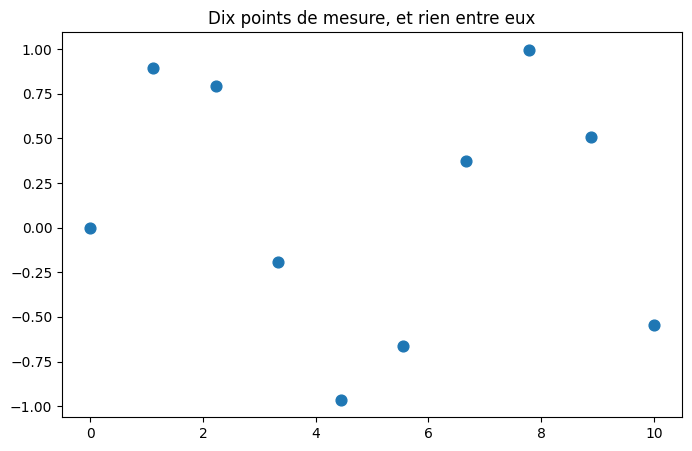

In [ ]:
x = np.linspace(0, 10, 10)
y = np.sin(x)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=60)
plt.title('Dix points de mesure, et rien entre eux')
plt.show()

`interp1d` renvoie une fonction. C'est le point qui surprend : l'objet `f`
n'est pas un tableau de résultats, c'est quelque chose qu'on appelle ensuite
avec de nouvelles abscisses.

<class 'scipy.interpolate._interpolate.interp1d'>
Points connus  : (10,)
Points estimés : (30,)


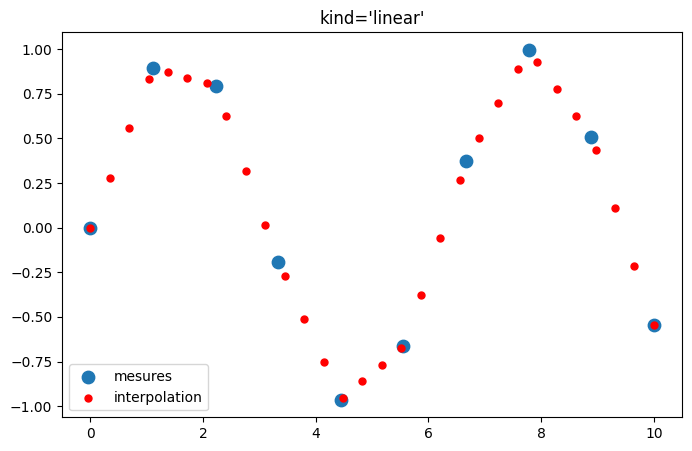

In [ ]:
from scipy.interpolate import interp1d

f = interp1d(x, y, kind='linear') # f est une fonction, pas un tableau
new_x = np.linspace(0, 10, 30) # 30 abscisses au lieu de 10
result = f(new_x) # on l'appelle ici

print(type(f))
print('Points connus  :', x.shape)
print('Points estimés :', result.shape)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80, label='mesures')
plt.scatter(new_x, result, c='r', s=25, label='interpolation')
plt.legend()
plt.title("kind='linear'")
plt.show()

### Comparer les méthodes

L'argument `kind` change la façon de relier les points. Plutôt que de relancer
la cellule cinq fois, une boucle permet de tout voir d'un coup.

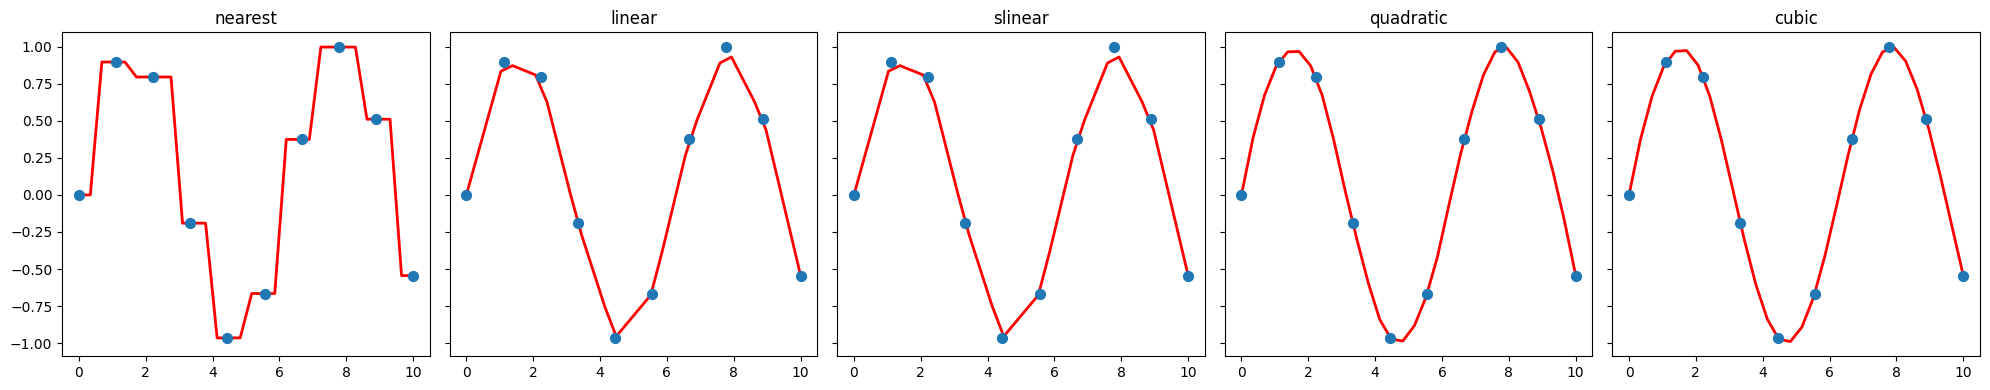

In [ ]:
methodes = ['nearest', 'linear', 'slinear', 'quadratic', 'cubic']

fig, ax = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, methode in enumerate(methodes):
    f = interp1d(x, y, kind=methode)
    ax[i].plot(new_x, f(new_x), c='r', lw=2)
    ax[i].scatter(x, y, s=50, zorder=3)
    ax[i].set_title(methode)

plt.tight_layout()
plt.show()

Ce qu'on voit sur cette rangée.

`nearest` produit un escalier : chaque point prend la valeur du plus proche
voisin. Brutal, mais utile pour des données catégorielles.

`linear` et `slinear` donnent le même résultat, une ligne brisée. La différence
est interne, `slinear` passe par le mécanisme des splines.

`quadratic` et `cubic` donnent des courbes lisses. `cubic` est le choix par
défaut dans la plupart des situations.

### Le piège des méthodes lisses

Une interpolation lisse peut inventer des oscillations qui n'existent pas dans
les données. Sur un sinus échantillonné trop grossièrement, la courbe cubique
peut dépasser les valeurs réelles entre deux points.

C'est le compromis permanent de l'interpolation : plus la méthode est lisse,
plus elle est agréable à l'oeil, et plus elle risque d'affirmer des choses que
les données ne disent pas.

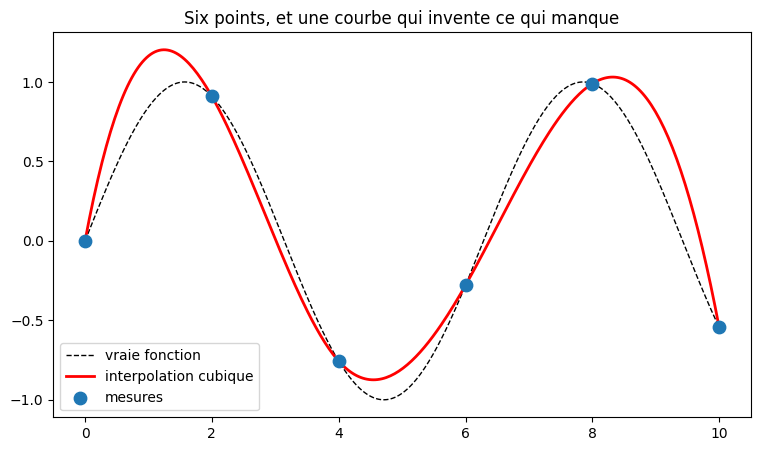

In [ ]:
x_grossier = np.linspace(0, 10, 6) # seulement 6 points
y_grossier = np.sin(x_grossier)

x_fin = np.linspace(0, 10, 300)

plt.figure(figsize=(9, 5))
plt.plot(x_fin, np.sin(x_fin), 'k--', lw=1, label='vraie fonction')
plt.plot(x_fin, interp1d(x_grossier, y_grossier, kind='cubic')(x_fin), c='r', lw=2, label='interpolation cubique')
plt.scatter(x_grossier, y_grossier, s=80, zorder=3, label='mesures')

plt.legend()
plt.title('Six points, et une courbe qui invente ce qui manque')
plt.show()

Un dernier point, technique celui-là : `interp1d` ne sait pas extrapoler. Lui
demander une valeur hors de l'intervalle des `x` connus lève une erreur.

In [ ]:
f = interp1d(x, y, kind='cubic')

try:
    f(15) # hors de l'intervalle [0, 10]
except ValueError as e:
    print('ValueError :', e)

ValueError : A value (15.0) in x_new is above the interpolation range's maximum value (10.0).


## 2. Optimisation : ajuster un modèle

On change de problème. Ici, les points ne sont plus fiables : ils sont bruités.
On ne veut donc plus passer par tous, mais trouver la courbe qui passe au mieux
au milieu.

Fabriquons des données bruitées à partir d'un polynôme connu, pour pouvoir
vérifier ensuite si l'ajustement retrouve les bons coefficients.

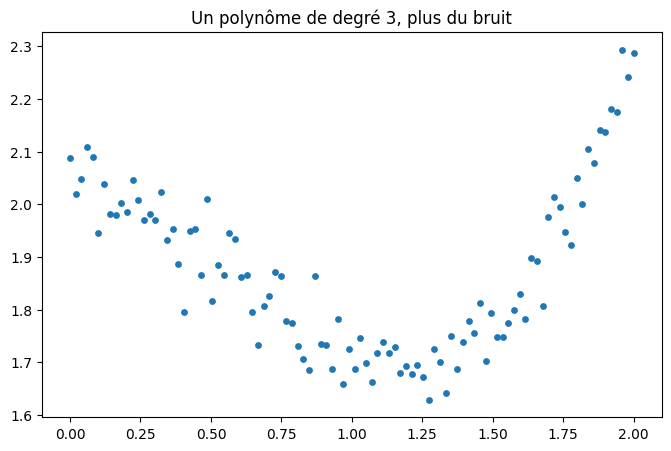

In [ ]:
np.random.seed(0)

x = np.linspace(0, 2, 100)
y = 1/3 * x**3 - 3/5 * x**2 + 2 + np.random.randn(x.shape[0]) / 20

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=15)
plt.title('Un polynôme de degré 3, plus du bruit')
plt.show()

`np.random.randn(x.shape[0])` tire cent valeurs selon une loi normale, une par
point. La division par 20 réduit l'amplitude du bruit. Sans `seed`, le résultat
changerait à chaque exécution, ce qui rend un notebook publié incohérent avec
ses propres commentaires.

### curve_fit

`curve_fit` prend une fonction modèle et cherche les paramètres qui minimisent
l'écart aux données. La convention est stricte : le premier argument de la
fonction est la variable, tous les suivants sont les paramètres à ajuster.

In [ ]:
from scipy import optimize

def modele(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

params, params_cov = optimize.curve_fit(modele, x, y)

print('Paramètres trouvés  :', params.round(3))
print('Paramètres attendus : [ 0.333 -0.6    0.     2.   ]')

Paramètres trouvés  : [ 0.337 -0.547 -0.128  2.052]
Paramètres attendus : [ 0.333 -0.6    0.     2.   ]


Les coefficients retrouvés sont proches de ceux qui ont servi à fabriquer les
données. C'est rassurant, mais c'est un cas facile : le modèle a exactement la
bonne forme.

Le second retour, `params_cov`, est la matrice de covariance des paramètres. Sa
diagonale donne la variance de chaque coefficient, donc l'incertitude sur
l'estimation.

In [ ]:
incertitudes = np.sqrt(np.diag(params_cov))

for nom, val, err in zip('abcd', params, incertitudes):
    print(f'{nom} = {val: .3f} ± {err:.3f}')

a =  0.337 ± 0.030
b = -0.547 ± 0.092
c = -0.128 ± 0.079
d =  2.052 ± 0.018


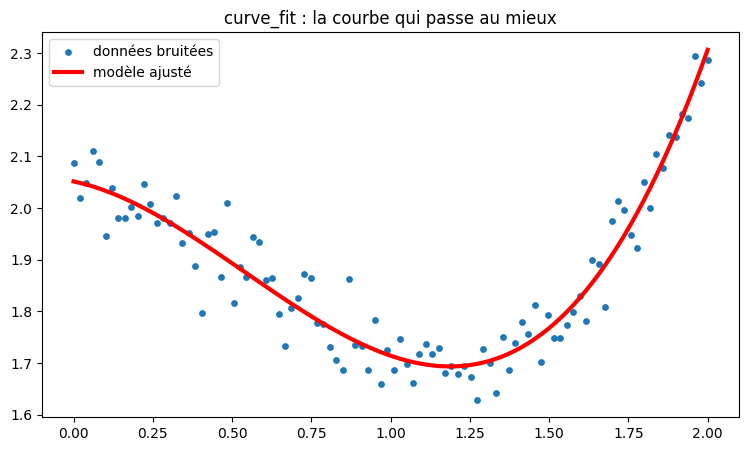

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=15, label='données bruitées')
plt.plot(x, modele(x, *params), c='r', lw=3, label='modèle ajusté')

plt.legend()
plt.title('curve_fit : la courbe qui passe au mieux')
plt.show()

Le `*params` déballe le tableau en quatre arguments séparés. Écrire
`modele(x, params[0], params[1], params[2], params[3])` donne le même résultat,
en quatre fois plus long et il faut tout réécrire si le modèle change de
degré.

Autre détail : `plt.plot` plutôt que `plt.scatter` pour la courbe ajustée. Le
modèle est une fonction continue, la représenter par des points isolés
suggérerait à tort qu'il s'agit de mesures.

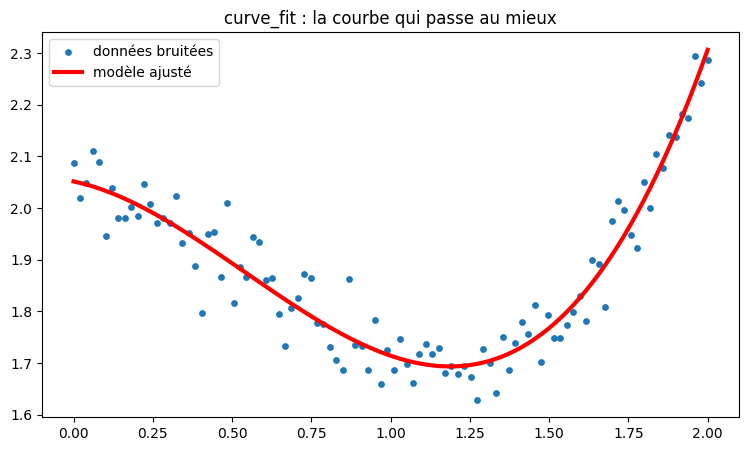

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=15, label='données bruitées')
plt.plot(x, modele(x, params[0], params[1], params[2], params[3]), c='r', lw=3, label='modèle ajusté')

plt.legend()
plt.title('curve_fit : la courbe qui passe au mieux')
plt.show()

## 3. Optimisation : chercher un minimum

Autre usage du module, sans rapport avec l'ajustement. Ici on a une fonction et
on cherche l'endroit où elle est la plus basse. C'est ce que fait, au fond,
l'entraînement de tout modèle de machine learning : minimiser une fonction de
coût.

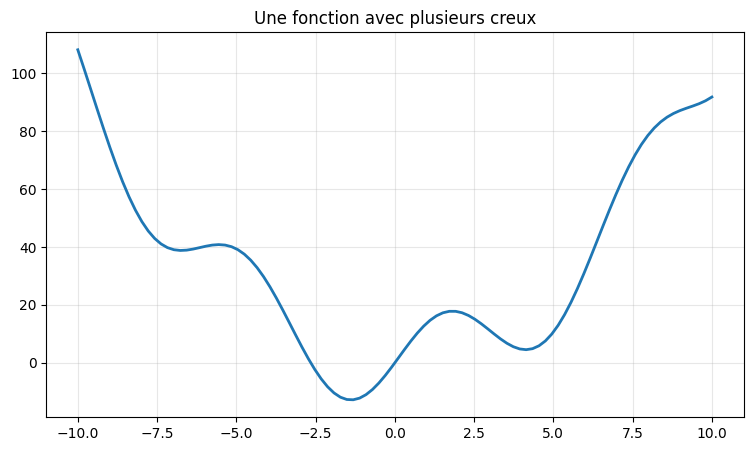

In [ ]:
def f(x):
    return x**2 + 15 * np.sin(x)

x = np.linspace(-10, 10, 100)

plt.figure(figsize=(9, 5))
plt.plot(x, f(x), lw=2)
plt.title('Une fonction avec plusieurs creux')
plt.grid(alpha=0.3)
plt.show()

Cette fonction a plusieurs minima locaux, et un seul minimum global. C'est
exactement la situation qui rend l'optimisation difficile.

`minimize` a besoin d'un point de départ, `x0`. Il descend ensuite dans la
pente, et s'arrête dans le premier creux rencontré.

In [ ]:
for depart in [-8, -5, 0, 5, 8]:
    resultat = optimize.minimize(f, x0=depart)
    print(f'départ x0 = {depart:3d}  ->  minimum en {resultat.x[0]: .3f}, ' f'f = {resultat.fun: .3f}')

départ x0 =  -8  ->  minimum en -6.738, f =  38.811
départ x0 =  -5  ->  minimum en -1.385, f = -12.824
départ x0 =   0  ->  minimum en -1.385, f = -12.824
départ x0 =   5  ->  minimum en  4.129, f =  4.530
départ x0 =   8  ->  minimum en  4.129, f =  4.530


Le résultat dépend du point de départ. Ce n'est pas un défaut de SciPy, c'est la
nature du problème : l'algorithme est aveugle, il ne voit que la pente sous ses
pieds.

Visualisons un cas où il se trompe.

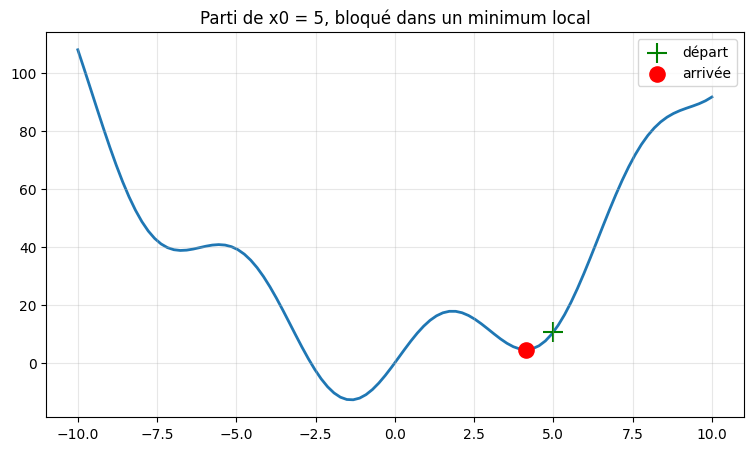

In [ ]:
x0 = 5
resultat = optimize.minimize(f, x0=x0)

plt.figure(figsize=(9, 5))
plt.plot(x, f(x), lw=2, zorder=-1)
plt.scatter(x0, f(x0), s=200, marker='+', c='g', zorder=1, label='départ')
plt.scatter(resultat.x, resultat.fun, s=120, c='r', zorder=1, label='arrivée')

plt.legend()
plt.title('Parti de x0 = 5, bloqué dans un minimum local')
plt.grid(alpha=0.3)
plt.show()

L'argument `zorder` gère la superposition : les valeurs élevées passent devant.
Sans lui, la courbe tracée en premier recouvrirait les points.

`minimize` renvoie un objet complet, pas seulement la solution. Il vaut la peine
de le regarder en entier, notamment `success` et `nit`, le nombre d'itérations.

In [ ]:
print(resultat)
resultat.x

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.529631081068029
        x: [ 4.129e+00]
      nit: 5
      jac: [ 1.192e-07]
 hess_inv: [[ 6.885e-02]]
     nfev: 12
     njev: 6


array([4.12933284])

### En deux dimensions

Le principe est identique, mais le point de départ devient un vecteur. C'est là
qu'une erreur classique se produit.

In [ ]:
def g(p): # p contient les deux coordonnées
    return np.sin(p[0]) + np.cos(p[0] + p[1]) * np.cos(p[0])

# Erreur fréquente : un tableau à deux dimensions
mauvais_x0 = np.zeros((2, 1))
print('forme :', mauvais_x0.shape, ' ndim :', mauvais_x0.ndim)

try:
    optimize.minimize(g, x0=mauvais_x0)
except ValueError as e:
    print('ValueError :', e)

forme : (2, 1)  ndim : 2
ValueError : 'x0' must only have one dimension.


`np.zeros((2, 1))` construit une matrice de deux lignes et une colonne.
`minimize` veut un vecteur simple. La correction tient à deux parenthèses.

In [ ]:
print(np.zeros((2, 1)).shape, np.zeros((2, 1)).ndim) # (2, 1)  2
print(np.zeros(2).shape,      np.zeros(2).ndim)  # (2,)    1

(2, 1) 2
(2,) 1


Départ  : [0. 0.]
Minimum : [-0.785 -2.356]
Valeur  : -1.414


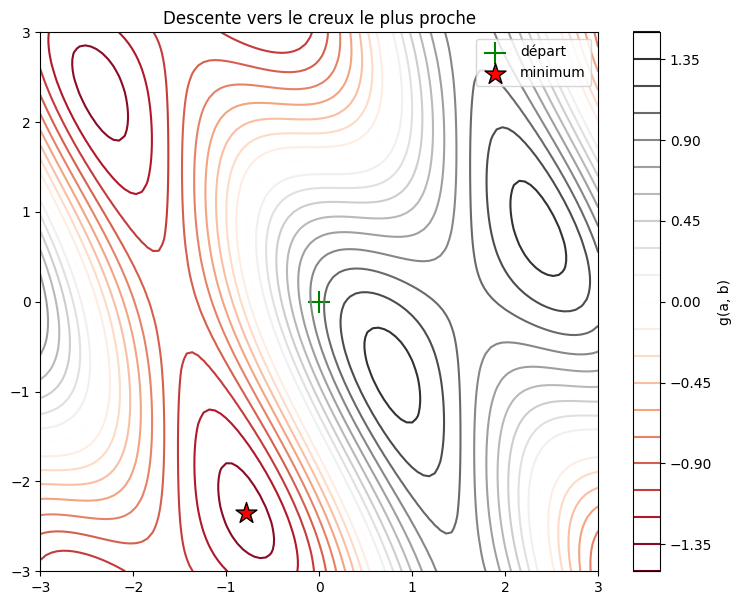

In [ ]:
# Grille pour le tracé. Noms doubles : x est déjà pris par le linspace ci-dessus.
XX = np.linspace(-3, 3, 100)
YY = np.linspace(-3, 3, 100)
XX, YY = np.meshgrid(XX, YY)
ZZ = g(np.array([XX, YY]))

x0 = np.zeros(2) # vecteur 1D, cette fois
resultat = optimize.minimize(g, x0=x0)

print('Départ  :', x0)
print('Minimum :', resultat.x.round(3))
print('Valeur  :', round(resultat.fun, 3))

plt.figure(figsize=(9, 7))
plt.contour(XX, YY, ZZ, 20, cmap='RdGy')
plt.colorbar(label='g(a, b)')

plt.scatter(x0[0], x0[1], marker='+', c='green', s=250, label='départ')
plt.scatter(resultat.x[0], resultat.x[1], marker='*', c='red', s=250,
            edgecolors='black', label='minimum')

plt.legend()
plt.title('Descente vers le creux le plus proche')
plt.show()

Le choix des noms `XX`, `YY`, `ZZ` évite d'écraser `x`, qui sert au tracé de la
fonction 1D quelques cellules plus haut. C'est le piège récurrent des notebooks :
les variables persistent et les cellules peuvent être exécutées dans le
désordre. Deux règles suffisent ne jamais réutiliser un nom pour deux choses
différentes, et redémarrer le noyau avant de publier pour vérifier que tout
tient dans l'ordre.

## 4. Traitement du signal

Un signal réel combine souvent plusieurs composantes : une tendance de fond, des
oscillations, du bruit. Les séparer est souvent la première étape de l'analyse.

### detrend : retirer la tendance

`detrend` ajuste une droite sur le signal et la soustrait. Ce qui reste est la
variation autour de la tendance.

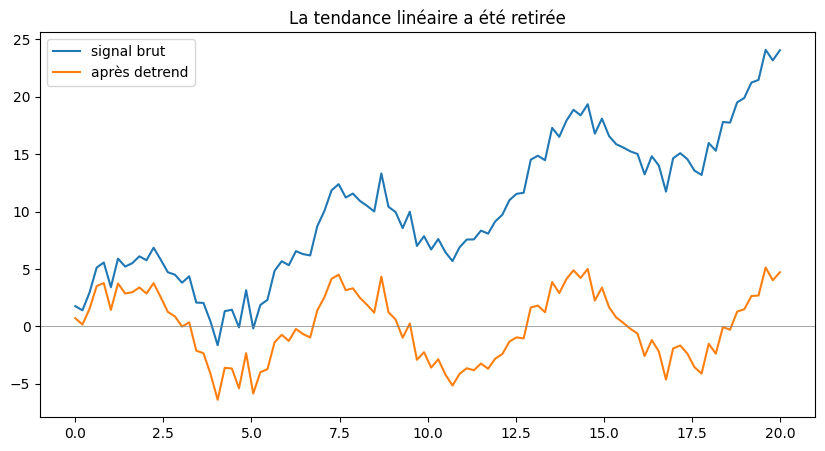

In [ ]:
np.random.seed(0)

x = np.linspace(0, 20, 100)
y = x + 4 * np.sin(x) + np.random.randn(x.shape[0])

from scipy import signal
new_y = signal.detrend(y)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='signal brut')
plt.plot(x, new_y, label='après detrend')
plt.axhline(0, color='gray', lw=0.5)

plt.legend()
plt.title('La tendance linéaire a été retirée')
plt.show()

Le signal d'origine monte régulièrement, à cause du terme `x`. Après `detrend`,
il oscille autour de zéro et les variations deviennent comparables entre le
début et la fin.

C'est utile chaque fois qu'une tendance masque ce qui nous intéresse : une série
temporelle avec une croissance de fond, un capteur qui dérive lentement.

### Analyse de Fourier

Un signal périodique peut se décomposer en une somme de sinusoïdes. La
transformée de Fourier donne l'amplitude de chaque fréquence présente, ce qui
permet de retrouver les périodicités cachées dans les données.

Fabriquons un signal contenant trois fréquences connues.

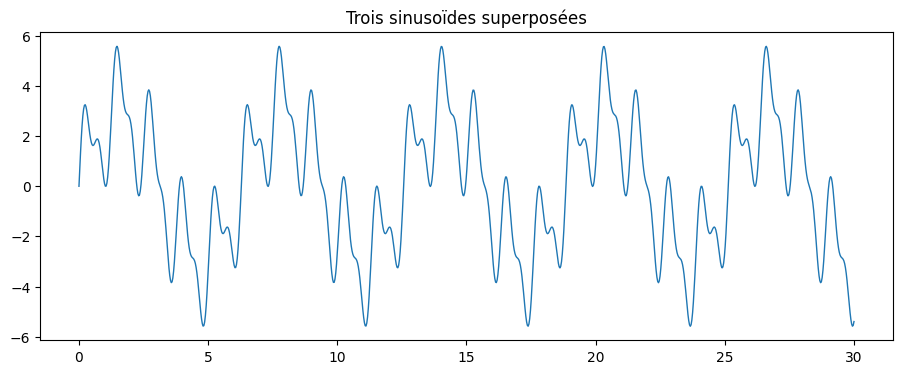

In [ ]:
x = np.linspace(0, 30, 1000)
y = 3 * np.sin(x) + 2 * np.sin(5 * x) + np.sin(10 * x)

plt.figure(figsize=(11, 4))
plt.plot(x, y, lw=1)
plt.title('Trois sinusoïdes superposées')
plt.show()

À l'oeil, on devine une structure répétitive, sans pouvoir dire laquelle. C'est
précisément ce que la transformée va révéler.

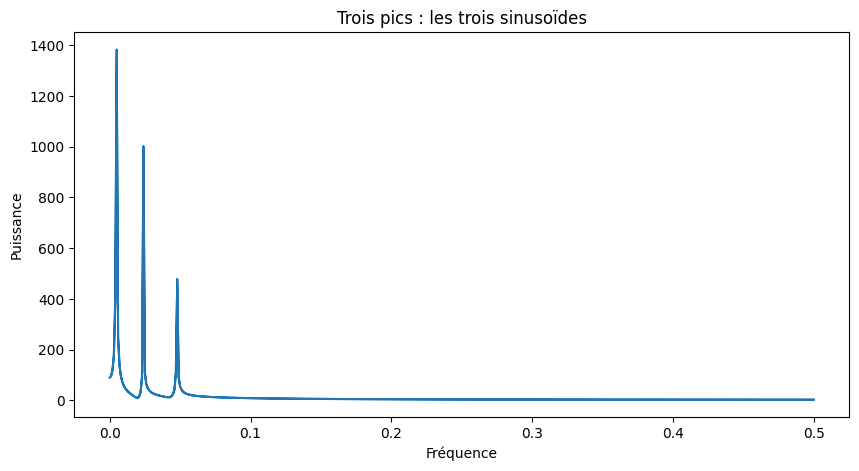

In [ ]:
from scipy import fft

transformee = fft.fft(y)
puissance = np.abs(transformee) # l'amplitude de chaque fréquence
frequences = fft.fftfreq(y.size) # attention, voir plus bas

plt.figure(figsize=(10, 5))
plt.plot(np.abs(frequences), puissance)
plt.xlabel('Fréquence')
plt.ylabel('Puissance')
plt.title('Trois pics : les trois sinusoïdes')
plt.show()

Trois pics apparaissent nettement, un par sinusoïde, et leur hauteur reflète
l'amplitude de chacune. Le signal a été décomposé.

### Un piège dans les valeurs affichées

Les fréquences lues sur ce graphique sont fausses. `fftfreq` ne connaît pas
l'échelle réelle de `x` : par défaut, il suppose un intervalle de 1 entre deux
points. Or ici, `linspace(0, 30, 1000)` donne un pas de 0,03.

Le paramètre `d` corrige cela.

In [ ]:
pas = x[1] - x[0]
frequences_justes = fft.fftfreq(y.size, d=pas)

# Les trois pics les plus hauts
sommets = np.argsort(puissance)[::-1][:6] # 6 car le spectre est symétrique

print('Fréquences lues sans d :', np.unique(np.abs(frequences[sommets]).round(4)))
print('Fréquences avec d :', np.unique(np.abs(frequences_justes[sommets]).round(3)))
print('Valeurs théoriques :', (np.array([1, 5, 10]) / (2 * np.pi)).round(3))

Fréquences lues sans d : [0.005 0.024 0.048]
Fréquences avec d : [0.166 0.799 1.598]
Valeurs théoriques : [0.159 0.796 1.592]


Avec le pas correct, on retrouve bien les fréquences attendues. Un signal en
`sin(k·x)` a une fréquence de k/2π, soit 0,159, 0,796 et 1,592 pour k valant 1,
5 et 10.

Sans le paramètre `d`, les valeurs affichées sont proportionnelles aux bonnes,
mais avec un facteur d'échelle arbitraire. La forme du graphique est correcte,
les nombres ne le sont pas. C'est un cas typique d'erreur silencieuse : aucun
message, un résultat crédible, et une conclusion fausse si on lit les
graduations.

Une remarque sur le module utilisé : `scipy.fftpack` fonctionne toujours mais
n'est plus maintenu. `scipy.fft` est son remplaçant, avec la même syntaxe.

### Filtrer le bruit

L'intérêt pratique de la transformée : le bruit se répartit sur toutes les
fréquences, alors que le signal utile se concentre sur quelques pics. On peut
donc supprimer les fréquences faibles et reconstruire un signal propre.

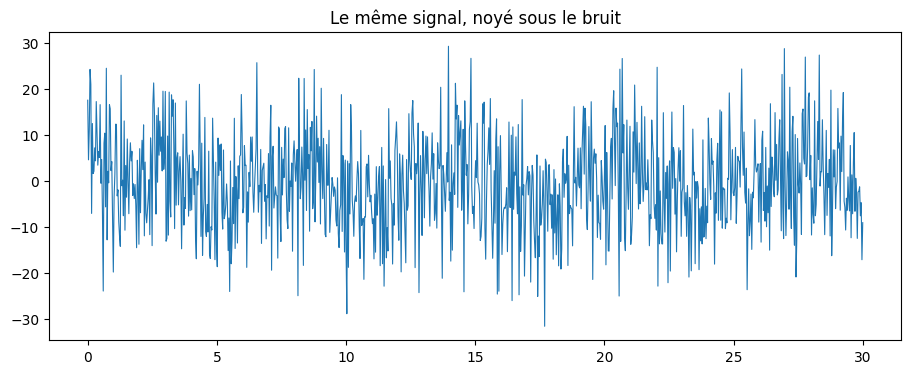

In [ ]:
np.random.seed(0)

y_bruite = (3 * np.sin(x) + 2 * np.sin(5 * x) + np.sin(10 * x) + np.random.randn(x.shape[0]) * 10)

plt.figure(figsize=(11, 4))
plt.plot(x, y_bruite, lw=0.8)
plt.title('Le même signal, noyé sous le bruit')
plt.show()

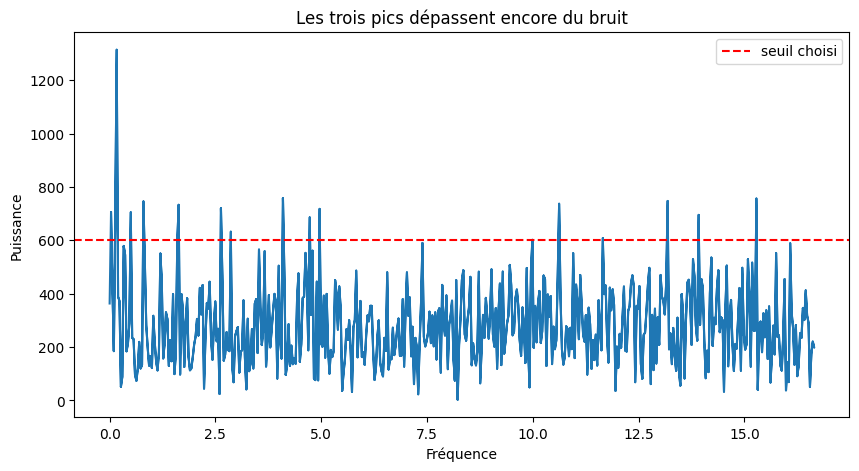

In [ ]:
transformee = fft.fft(y_bruite)
puissance = np.abs(transformee)

plt.figure(figsize=(10, 5))
plt.plot(np.abs(fft.fftfreq(y_bruite.size, d=pas)), puissance)
plt.axhline(600, color='red', ls='--', label='seuil choisi')
plt.xlabel('Fréquence')
plt.ylabel('Puissance')
plt.legend()
plt.title('Les trois pics dépassent encore du bruit')
plt.show()

Malgré le bruit, les trois pics restent visibles. Tout ce qui est en dessous du
seuil peut être considéré comme parasite.

Le seuil de 600 est choisi à l'oeil sur ce graphique. Ce n'est pas une méthode
rigoureuse, mais c'est ainsi qu'on procède en pratique pour un premier essai.

In [ ]:
transformee_filtree = transformee.copy() # copie, pour garder l'original
transformee_filtree[puissance < 600] = 0 # on annule les faibles

signal_filtre = fft.ifft(transformee_filtree) # transformée inverse

print('Type du résultat  :', signal_filtre.dtype)
print('Partie imaginaire :', np.abs(signal_filtre.imag).max())

Type du résultat  : complex128
Partie imaginaire : 1.8179122055658495e-15


`ifft` renvoie des nombres complexes. La partie imaginaire est ici de l'ordre de
10⁻¹⁵, donc nulle à la précision machine : c'est un résidu de calcul, pas une
information.

Matplotlib affiche un avertissement si on lui passe des complexes. Le `.real`
règle le problème et rend explicite qu'on sait ce qu'on fait.

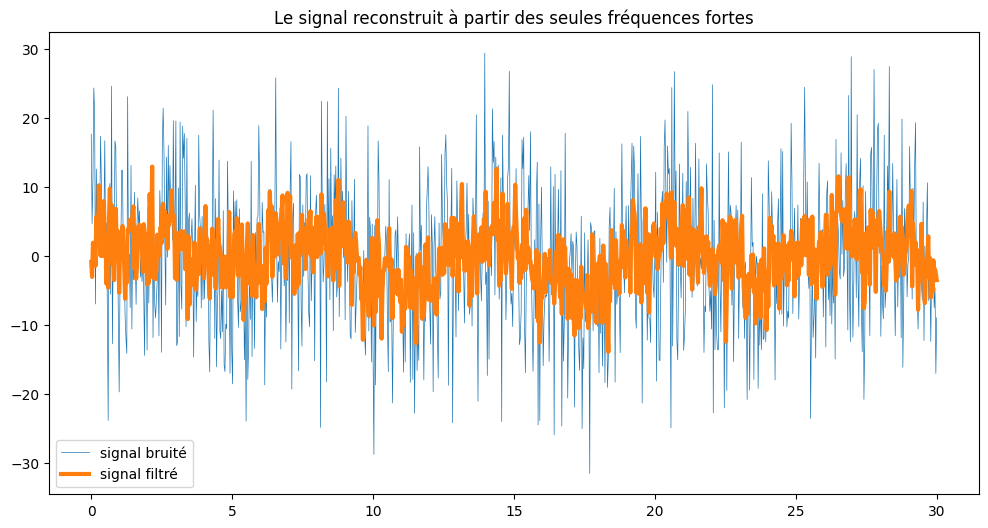

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x, y_bruite, lw=0.5, label='signal bruité')
plt.plot(x, signal_filtre.real, lw=3, label='signal filtré')

plt.legend()
plt.title('Le signal reconstruit à partir des seules fréquences fortes')
plt.show()

Le signal d'origine ressort du bruit. Le principe est celui de tous les filtres
audio, de la compression MP3 et de nombreuses techniques de débruitage : passer
dans le domaine des fréquences, y faire le tri, revenir.

À tester : abaisse le seuil à 200, puis monte-le à 1500. Trop bas, le bruit
revient ; trop haut, on perd la sinusoïde la plus faible. C'est le compromis
habituel entre débruitage et perte d'information.

Type du résultat  : complex128
Partie imaginaire : 5.518332415357218e-15


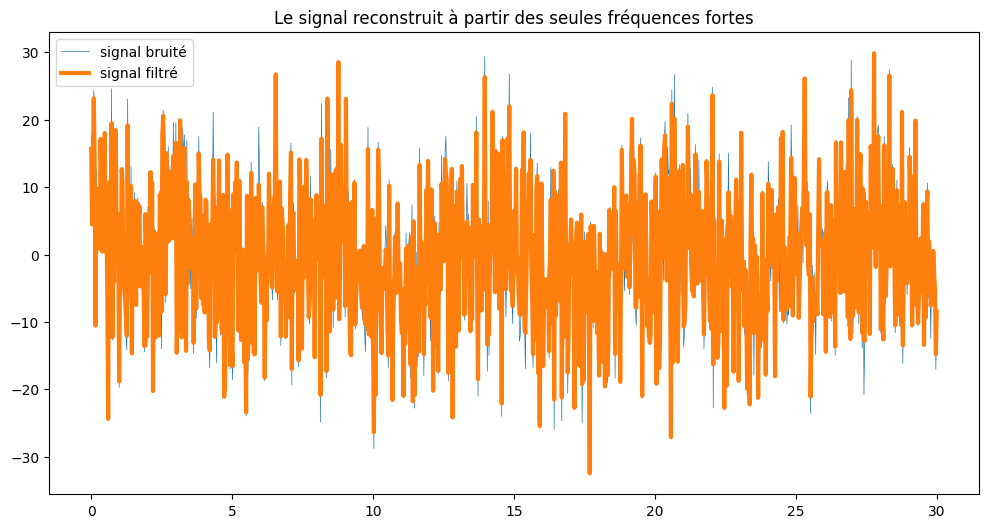

In [ ]:
transformee_filtree = transformee.copy() # copie, pour garder l'original
transformee_filtree[puissance < 200] = 0 # on annule les faibles

signal_filtre = fft.ifft(transformee_filtree) # transformée inverse

print('Type du résultat  :', signal_filtre.dtype)
print('Partie imaginaire :', np.abs(signal_filtre.imag).max())

plt.figure(figsize=(12, 6))
plt.plot(x, y_bruite, lw=0.5, label='signal bruité')
plt.plot(x, signal_filtre.real, lw=3, label='signal filtré')

plt.legend()
plt.title('Le signal reconstruit à partir des seules fréquences fortes')
plt.show()


Type du résultat  : complex128
Partie imaginaire : 0.0


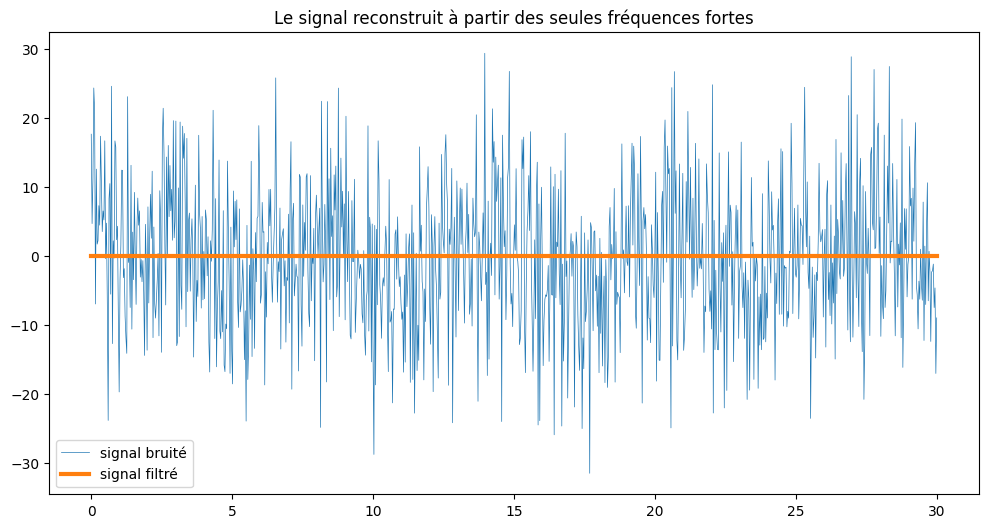

In [ ]:
transformee_filtree = transformee.copy() # copie, pour garder l'original
transformee_filtree[puissance < 1500] = 0 # on annule les faibles

signal_filtre = fft.ifft(transformee_filtree) # transformée inverse

print('Type du résultat  :', signal_filtre.dtype)
print('Partie imaginaire :', np.abs(signal_filtre.imag).max())

plt.figure(figsize=(12, 6))
plt.plot(x, y_bruite, lw=0.5, label='signal bruité')
plt.plot(x, signal_filtre.real, lw=3, label='signal filtré')

plt.legend()
plt.title('Le signal reconstruit à partir des seules fréquences fortes')
plt.show()


## 5. Traitement d'images : compter des objets

`ndimage` traite les images comme des tableaux. On va s'en servir pour un
problème concret : compter automatiquement des objets sur une image.

Commençons par une image synthétique, un carré parasité par des pixels isolés.

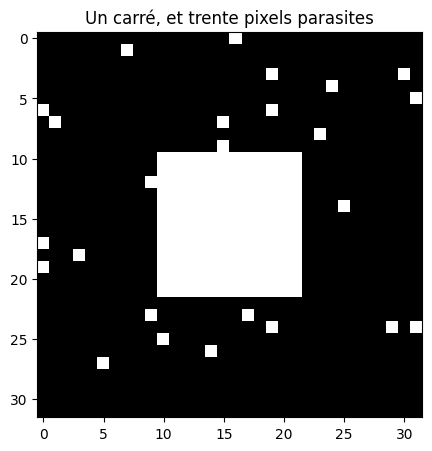

In [ ]:
from scipy import ndimage

np.random.seed(0)

X = np.zeros((32, 32))
X[10:-10, 10:-10] = 1  # un carré central
X[np.random.randint(0, 32, 30), np.random.randint(0, 32, 30)] = 1 # du bruit

plt.figure(figsize=(5, 5))
plt.imshow(X, cmap='gray')
plt.title('Un carré, et trente pixels parasites')
plt.show()

### L'ouverture morphologique

`binary_opening` supprime les détails plus petits que la structure de test, tout
en préservant les formes plus grandes. C'est l'outil de base pour nettoyer une
image binaire.

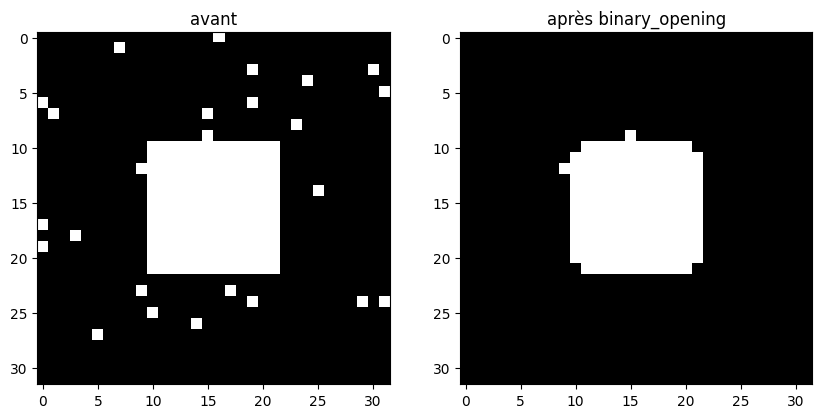

In [ ]:
X_propre = ndimage.binary_opening(X)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(X, cmap='gray')
ax[0].set_title('avant')

ax[1].imshow(X_propre, cmap='gray')
ax[1].set_title('après binary_opening')
plt.show()

Les pixels isolés ont disparu, le carré est intact. C'est exactement ce qu'on
veut avant de compter des objets : sans ce nettoyage, chaque grain de bruit
serait compté comme un objet.

### Sur une vraie image


Forme :  (303, 384)
Type :  uint8
Valeurs : de 1 à 252


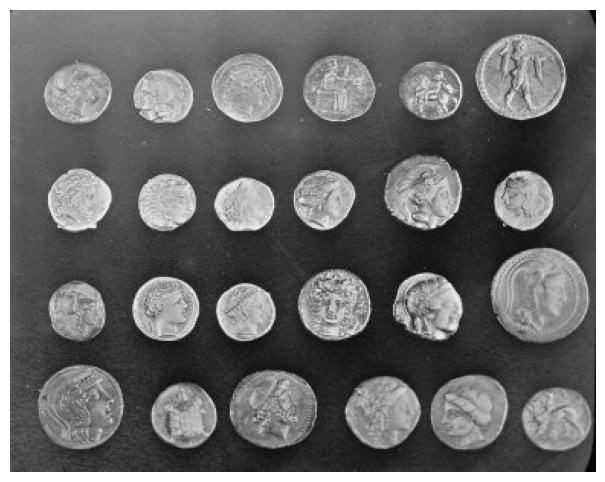

In [ ]:
from skimage import data

image = data.coins() # pièces de monnaie, niveaux de gris

print('Forme : ', image.shape)
print('Type : ', image.dtype)
print('Valeurs : de', image.min(), 'à', image.max())

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

La forme `(303, 384)` indique une image en niveaux de gris, un tableau à deux
dimensions. Une image couleur aurait une troisième dimension pour les canaux
rouge, vert et bleu, et il faudrait alors écrire `image[:, :, 0]` pour n'en
garder qu'un.

### L'histogramme décide du seuil

Pour séparer les objets du fond, il faut un seuil. L'histogramme des intensités
le donne : deux populations produisent deux bosses, et le creux entre elles est
le seuil naturel.

`ravel` aplatit le tableau 2D en un long vecteur, car `hist` ne travaille que
sur une dimension.

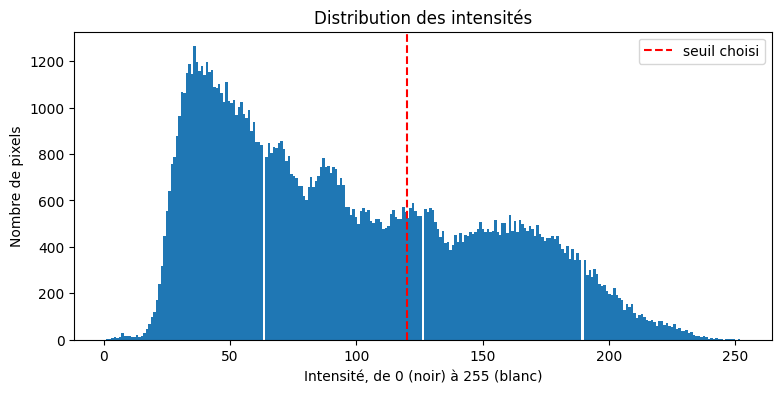

In [ ]:
plt.figure(figsize=(9, 4))
plt.hist(image.ravel(), bins=255)
plt.axvline(120, color='red', ls='--', label='seuil choisi')
plt.xlabel('Intensité, de 0 (noir) à 255 (blanc)')
plt.ylabel('Nombre de pixels')
plt.legend()
plt.title('Distribution des intensités')
plt.show()

Type du résultat : bool
Proportion de True : 0.329


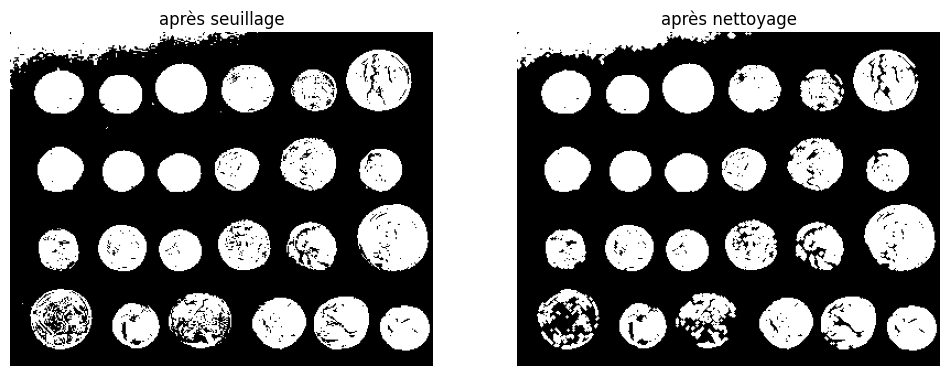

In [ ]:
binaire = image > 120  # True pour les pixels clairs
print('Type du résultat :', binaire.dtype)
print('Proportion de True :', round(binaire.mean(), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(binaire, cmap='gray');  ax[0].set_title('après seuillage')
ax[1].imshow(ndimage.binary_opening(binaire), cmap='gray')
ax[1].set_title('après nettoyage')
for a in ax: a.axis('off')
plt.show()

La comparaison `image > 120` produit un tableau de booléens, un par pixel. C'est
le masque booléen de NumPy, appliqué ici à deux dimensions.

Un détail à ne pas manquer : écrire `image = image > 120` écraserait l'image
d'origine. Impossible ensuite de réessayer avec un autre seuil sans tout
recharger. Un nom distinct coûte moins cher.

### Étiqueter et compter

`label` parcourt l'image et attribue un numéro à chaque groupe de pixels
connectés. Le fond reçoit le numéro 0, les objets les numéros 1, 2, 3, et ainsi
de suite.

Nombre d'objets détectés : 59
Valeurs présentes : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]


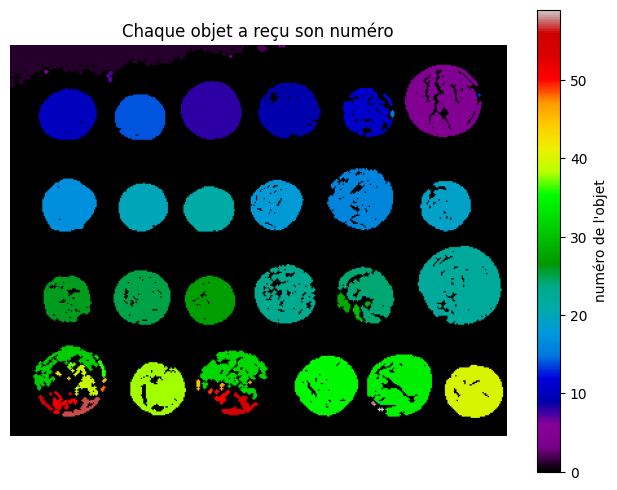

In [ ]:
propre = ndimage.binary_opening(binaire)
etiquettes, n_objets = ndimage.label(propre)

print('Nombre d\'objets détectés :', n_objets)
print('Valeurs présentes :', np.unique(etiquettes))

plt.figure(figsize=(8, 6))
plt.imshow(etiquettes, cmap='nipy_spectral')
plt.colorbar(label="numéro de l'objet")
plt.axis('off')
plt.title('Chaque objet a reçu son numéro')
plt.show()

### Le piège du comptage

Il reste à mesurer la taille de chaque objet. C'est ici que se cache l'erreur la
plus courante, et elle ne lève aucun message.

In [ ]:
# La version fausse
tailles_faux = ndimage.sum_labels(propre, etiquettes, range(n_objets))

# La version correcte
tailles = ndimage.sum_labels(propre, etiquettes, range(1, n_objets + 1))

print('Avec range(n)      :', tailles_faux[:5].astype(int), '...')
print('Avec range(1, n+1) :', tailles[:5].astype(int), '...')
print()
print('Longueurs :', len(tailles_faux), 'contre', len(tailles))

Avec range(n)      : [   0 2868   32   10    5] ...
Avec range(1, n+1) : [2868   32   10    5 2297] ...

Longueurs : 59 contre 59


`range(n_objets)` va de 0 à n-1. Il demande donc la taille de l'étiquette 0, qui
est le fond, et n'atteint jamais l'étiquette n, le dernier objet.

Résultat : la première valeur est aberrante, et un objet manque à l'appel. Le
tableau a la bonne longueur, les nombres ont l'air plausibles, et rien ne
signale le problème. C'est le genre d'erreur qui traverse un projet entier.

La règle : les étiquettes vont de 1 à `n_objets`, donc l'intervalle est
`range(1, n_objets + 1)`.

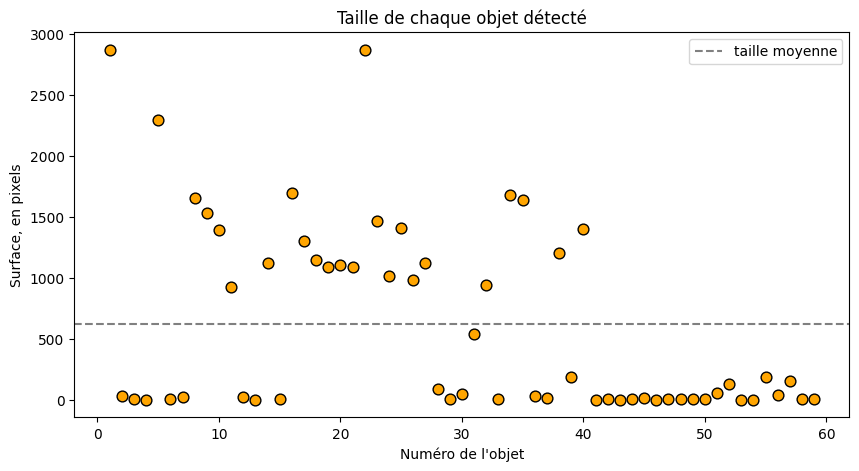

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(range(1, n_objets + 1), tailles, c='orange', s=60, edgecolors='black')
plt.axhline(tailles.mean(), color='gray', ls='--', label='taille moyenne')

plt.xlabel("Numéro de l'objet")
plt.ylabel('Surface, en pixels')
plt.legend()
plt.title('Taille de chaque objet détecté')
plt.show()

Ce graphique sert à repérer les détections douteuses. Les objets très petits
sont souvent des restes de bruit, les très gros des objets collés que le
seuillage n'a pas su séparer.

Filtrer sur la taille est le dernier nettoyage :

```python
vrais_objets = tailles[tailles > 100]
print(f'{len(vrais_objets)} objets après filtrage sur la taille')
```

C'est la chaîne complète du comptage automatique : seuiller, nettoyer,
étiqueter, mesurer, filtrer. Elle s'applique aussi bien à des bactéries qu'à des
cellules, des grains ou des pièces sur un tapis roulant.

## 6. Mémo

### Les fonctions du notebook

| Besoin | Fonction |
|---|---|
| Estimer entre des points connus | `interpolate.interp1d` |
| Ajuster un modèle sur des données bruitées | `optimize.curve_fit` |
| Trouver le minimum d'une fonction | `optimize.minimize` |
| Retirer une tendance linéaire | `signal.detrend` |
| Décomposer en fréquences | `fft.fft` et `fft.fftfreq` |
| Revenir au signal temporel | `fft.ifft` |
| Nettoyer une image binaire | `ndimage.binary_opening` |
| Numéroter les objets | `ndimage.label` |
| Mesurer chaque objet | `ndimage.sum_labels` |

### Les erreurs silencieuses

Celles-ci ne lèvent aucun message et donnent un résultat crédible.

| Erreur | Conséquence |
|---|---|
| `fftfreq` sans le paramètre `d` | fréquences fausses d'un facteur d'échelle |
| `range(n_objets)` au lieu de `range(1, n+1)` | le fond compté, le dernier objet oublié |
| `image = image > seuil` | l'image d'origine perdue |
| Interpolation lisse sur peu de points | oscillations inventées |

### Les erreurs bruyantes

| Message | Cause |
|---|---|
| `'x0' must only have one dimension` | `np.zeros((2, 1))` au lieu de `np.zeros(2)` |
| `A value in x_new is above the interpolation range` | extrapolation hors intervalle |
| Avertissement sur les complexes | `ifft` sans `.real` |

## 7. Exercices

**Exercice 1**

Reprends le signal bruité de la section 4 et écris une fonction
`filtrer(y, seuil)` qui renvoie le signal filtré. Trace le résultat pour trois
seuils différents sur une même figure, et conclus sur le compromis.

**Exercice 2**

La fonction `f(x) = x² + 15·sin(x)` de la section 3 a plusieurs minima locaux.
Lance `minimize` depuis cinquante points de départ répartis entre -10 et 10,
puis trace un graphique montrant, pour chaque point de départ, le minimum
atteint. Combien de creux distincts trouves-tu, et lequel est le minimum global ?

**Exercice 3**

Sur l'image de pièces, fais varier le seuil de 80 à 180 et trace le nombre
d'objets détectés en fonction du seuil. Le résultat est-il stable ? Que
conclus-tu sur la fiabilité d'un seuil choisi à l'oeil ?

## Pour continuer

`scipy.stats` n'a pas été abordé ici et mérite un notebook à lui seul : lois de
probabilité, tests statistiques, corrélations. C'est le module qu'on utilise
pour justifier qu'un résultat n'est pas dû au hasard.

Pour le traitement d'images, `scikit-image` va nettement plus loin que
`ndimage` : seuillage automatique avec `threshold_otsu`, segmentation,
détection de contours. Le seuil choisi à l'oeil de la section 5 y devient un
calcul.

In [ ]:
# Exercice 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft

np.random.seed(0)

x = np.linspace(0, 30, 1000)
signal_pur = 3 * np.sin(x) + 2 * np.sin(5 * x) + np.sin(10 * x)
y = signal_pur + np.random.randn(x.shape[0]) * 10

pas = x[1] - x[0]


In [ ]:
def filtrer(y, seuil):
    transformee = fft.fft(y)
    puissance = np.abs(transformee)

    transformee_filtree = transformee.copy() # copie : on ne touche pas à l'original
    transformee_filtree[puissance < seuil] = 0

    return fft.ifft(transformee_filtree).real # .real : partie imaginaire nulle

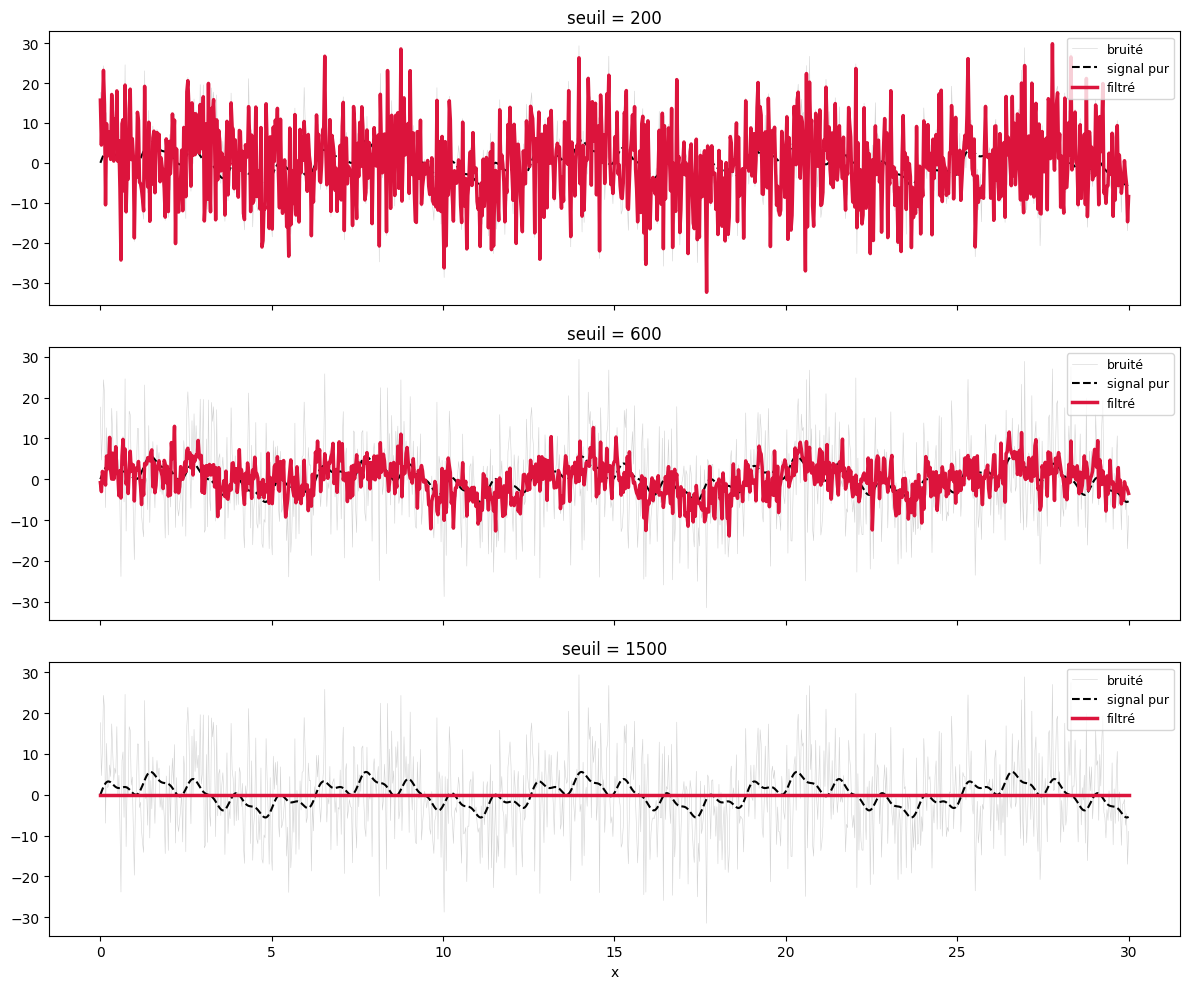

In [ ]:
seuils = [200, 600, 1500]

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i, seuil in enumerate(seuils):
    ax[i].plot(x, y, lw=0.4, color='lightgray', label='bruité')
    ax[i].plot(x, signal_pur, lw=1.5, color='black', ls='--', label='signal pur')
    ax[i].plot(x, filtrer(y, seuil), lw=2.5, color='crimson', label='filtré')
    ax[i].set_title(f'seuil = {seuil}')
    ax[i].legend(loc='upper right', fontsize=9)

ax[2].set_xlabel('x')
plt.tight_layout()
plt.show()

In [ ]:
def erreur(seuil):
    return np.mean((filtrer(y, seuil) - signal_pur) ** 2)


In [ ]:
grille = np.arange(0, 3000, 25)
erreurs = [erreur(s) for s in grille]
meilleur = grille[np.argmin(erreurs)]

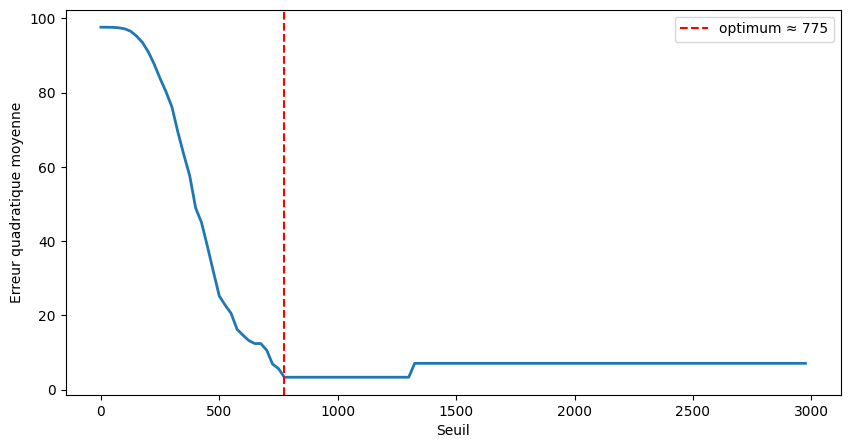

Seuil optimal : 775


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(grille, erreurs, lw=2)
plt.axvline(meilleur, color='red', ls='--', label=f'optimum ≈ {meilleur}')
plt.xlabel('Seuil')
plt.ylabel('Erreur quadratique moyenne')
plt.legend()
plt.show()
print('Seuil optimal :', meilleur)

In [ ]:
# Exerice 2

In [ ]:
from scipy import optimize

In [ ]:
def f(x):
    return x**2 + 15 * np.sin(x)

In [ ]:
departs = np.linspace(-10, 10, 50)
arrivees = np.array([optimize.minimize(f, x0=d).x[0] for d in departs])
minima = np.unique(arrivees.round(3))

In [ ]:
for m in minima:
    combien = np.sum(np.isclose(arrivees, m, atol=1e-2))
    print(f'x = {m:7.3f}   f(x) = {f(m):8.3f}   atteint {combien:2d} fois sur 50')

x =  -6.738   f(x) =   38.811   atteint 10 fois sur 50
x =  -1.385   f(x) =  -12.824   atteint 20 fois sur 50
x =   4.129   f(x) =    4.530   atteint 20 fois sur 50


In [ ]:
global_ = minima[np.argmin(f(minima))]
print(f'\n Minimum global : x = {global_:.3f}, f = {f(global_):.3f}')


 Minimum global : x = -1.385, f = -12.824


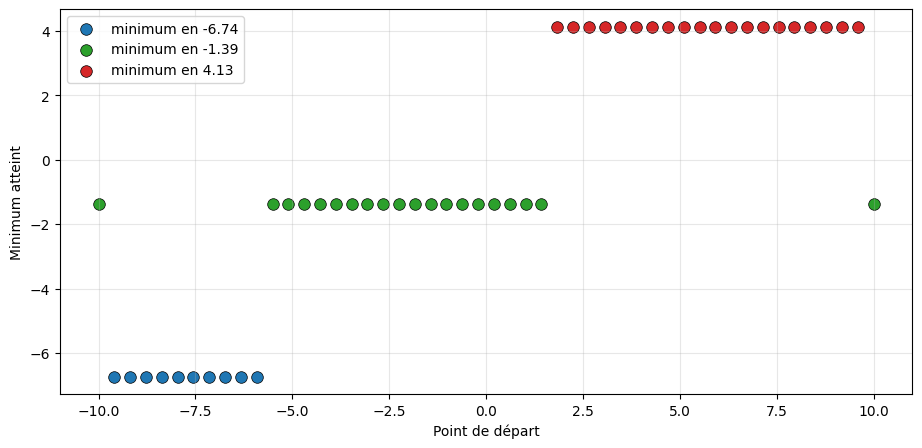

In [ ]:
couleurs = ['tab:blue', 'tab:green', 'tab:red']
plt.figure(figsize=(11, 5))
for i, m in enumerate(minima):
    masque = np.isclose(arrivees, m, atol=1e-2)
    plt.scatter(departs[masque], arrivees[masque], c=couleurs[i], s=70, edgecolors='black', linewidths=0.5, label=f'minimum en {m:.2f}')

plt.xlabel('Point de départ')
plt.ylabel('Minimum atteint')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

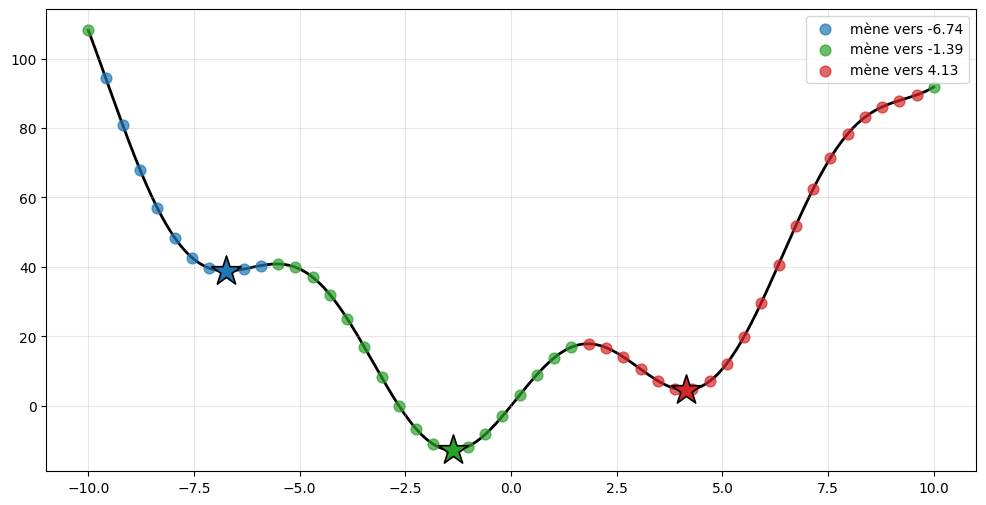

In [ ]:
xs = np.linspace(-10, 10, 500)

plt.figure(figsize=(12, 6))
plt.plot(xs, f(xs), lw=2, color='black', zorder=1)

for i, m in enumerate(minima):
    masque = np.isclose(arrivees, m, atol=1e-2)
    plt.scatter(departs[masque], f(departs[masque]), c=couleurs[i], s=60, zorder=2, alpha=0.7, label=f'mène vers {m:.2f}')
    plt.scatter(m, f(m), marker='*', s=500, c=couleurs[i], edgecolors='black', linewidths=1.2, zorder=3)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Multistart : beaucoup de départs, on garde le meilleur
essais = np.linspace(-10, 10, 200)
res = np.array([optimize.minimize(f, x0=d).x[0] for d in essais])
print('Multistart :', res[np.argmin(f(res))].round(4))

Multistart : -1.3851


In [ ]:
# Un algorithme conçu pour le global
r = optimize.differential_evolution(lambda p: f(p[0]), bounds=[(-10, 10)])
print('Évolution différentielle :', r.x[0].round(4))

Évolution différentielle : -1.3851


In [ ]:
# Exercice 3

array([[ 47, 123, 133, ...,  14,   3,  12],
       [ 93, 144, 145, ...,  12,   7,   7],
       [126, 147, 143, ...,   2,  13,   3],
       ...,
       [ 81,  79,  74, ...,   6,   4,   7],
       [ 88,  82,  74, ...,   5,   7,   8],
       [ 91,  79,  68, ...,   4,  10,   7]], dtype=uint8)
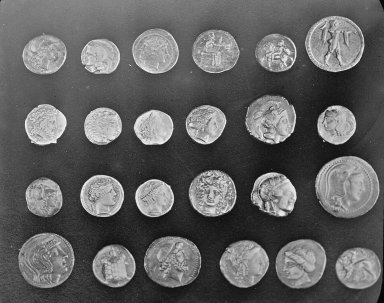

In [ ]:
from scipy import ndimage
from skimage import data

image = data.coins()  # 24 pièces, on connaît la réponse
image

In [ ]:
def compter(seuil, taille_min=0):
    binaire = image > seuil
    propre = ndimage.binary_opening(binaire)
    etiquettes, n = ndimage.label(propre)
    if n == 0:
        return 0
    tailles = ndimage.sum_labels(propre, etiquettes, range(1, n + 1))
    return int(np.sum(tailles > taille_min))

In [ ]:
seuils = np.arange(80, 181, 5)

In [ ]:
bruts = np.array([compter(s) for s in seuils])
filtres = np.array([compter(s, taille_min=100) for s in seuils])

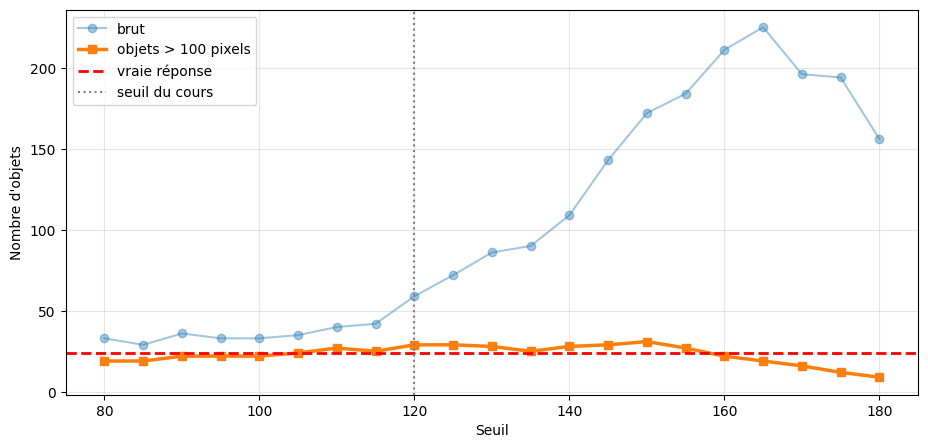

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(seuils, bruts, marker='o', lw=1.5, alpha=0.4, label='brut')
plt.plot(seuils, filtres, marker='s', lw=2.5, label='objets > 100 pixels')
plt.axhline(24, color='red', ls='--', lw=2, label='vraie réponse')
plt.axvline(120, color='gray', ls=':', label='seuil du cours')

plt.xlabel('Seuil')
plt.ylabel("Nombre d'objets")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

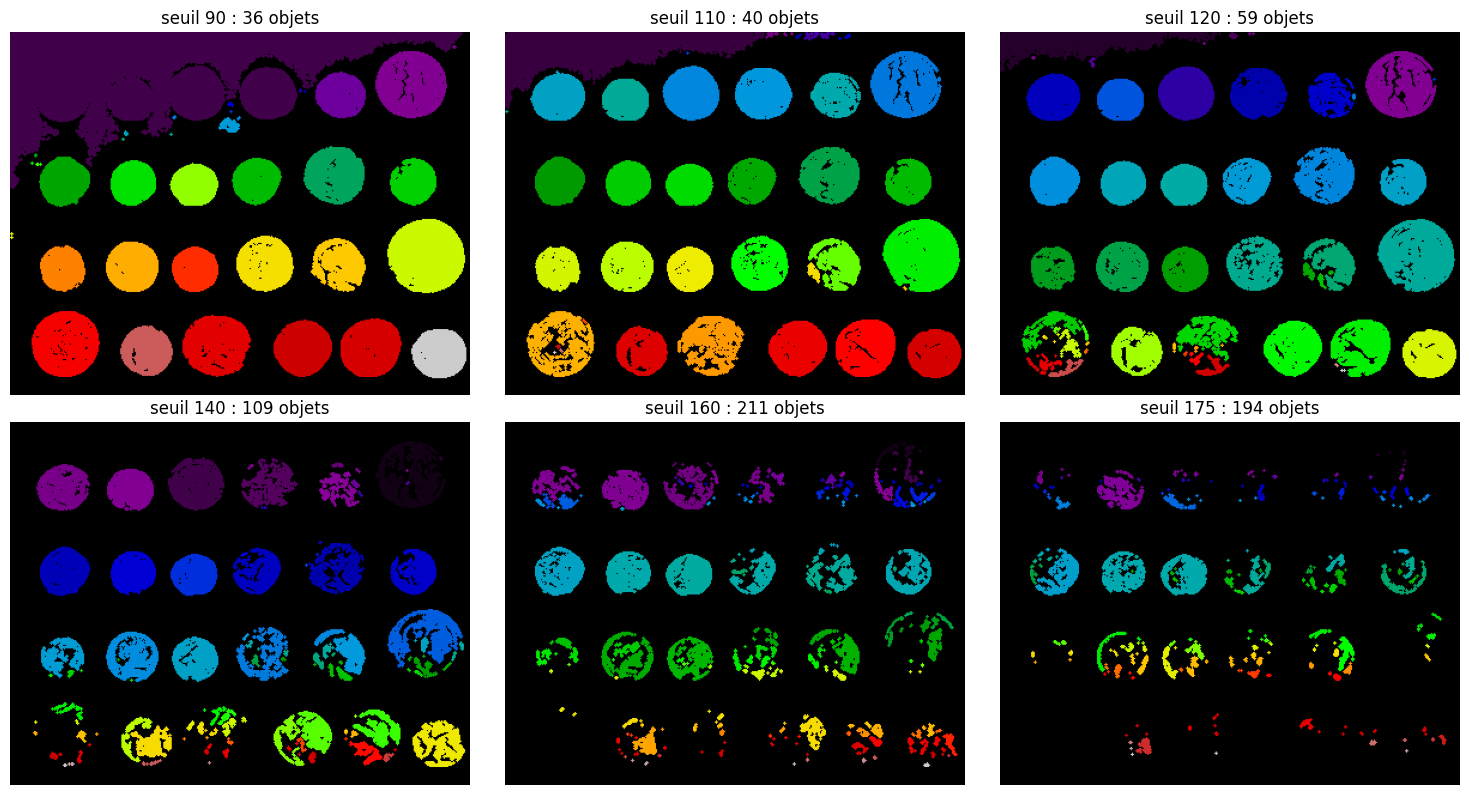

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()

for i, s in enumerate([90, 110, 120, 140, 160, 175]):
    propre = ndimage.binary_opening(image > s)
    etiquettes, n = ndimage.label(propre)
    ax[i].imshow(etiquettes, cmap='nipy_spectral')
    ax[i].set_title(f'seuil {s} : {n} objets')
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from skimage.filters import threshold_otsu, threshold_local

otsu = threshold_otsu(image)
print('Otsu :', otsu, '->', compter(otsu, taille_min=100), 'objets')

seuil_local = threshold_local(image, block_size=91, offset=-15)
binaire = image > seuil_local
propre = ndimage.binary_opening(binaire)
etiquettes, n = ndimage.label(propre)
tailles = ndimage.sum_labels(propre, etiquettes, range(1, n + 1))
print('Seuillage local :', int(np.sum(tailles > 100)), 'objets')

Otsu : 107 -> 26 objets
Seuillage local : 25 objets
